# Visualización de Persistencia Homológica

## A) Visión Industrial: Inspección de Defectos

### El juguete de Intuición

**Instrucciones**:


El Juguete de Intuición (15 min)
Antes de cargar imágenes reales, programen la intuición:

1. Creen dos matrices (imágenes) en numpy de 10x10.
2. Imagen A: Un cuadrado sólido (lleno de 1s).
3. Imagen B: Un cuadrado sólido con un bloque central de 3x3 lleno de 0s (un agujero).
4. Apliquen CubicalPersistence y grafiquen el Barcode.

* Observación: La Imagen B mostrará una barra larga en H₁ (agujero). ¡Detectaron un defecto sin redes neuronales!

In [2]:
# ------------ Importar Librerías
import numpy as np
#import pandas as pd
#import gudhi #este no era, me equivoqué
import gtda
from gtda.homology import CubicalPersistence

import matplotlib.pyplot as plt
from gtda.homology import CubicalPersistence
from gtda.plotting import plot_diagram

In [3]:
# verificar versiones, porque tuve q hacer un entorno virtual
import sklearn
import gtda
print("sklearn:", sklearn.__version__)
print("gtda:", gtda.__version__)
print("numpy:", np.__version__)

sklearn: 1.3.2
gtda: 0.6.2
numpy: 1.26.4


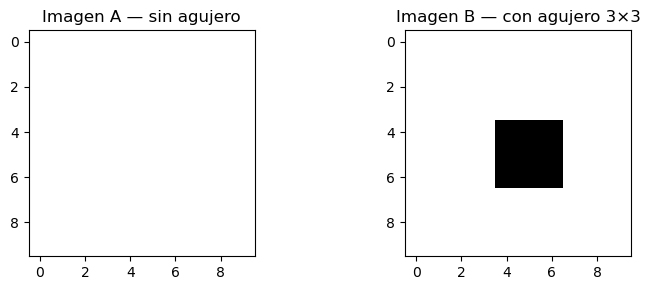

In [4]:
# Paso 1-2: crear imagen A (sólida) e imagen B (con hoyo)
imagenA = np.ones((10, 10))
imagenB = np.ones((10, 10))

# Paso 3: ponemos el bloque central 3x3 en 0 → ese es el 'agujero'
# índices 4:7 seleccionan filas/cols 4,5,6 → centro de la matriz 10x10
imagenB[4:7, 4:7] = 0

# visualizamos las dos imágenes para confirmar
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(imagenA, cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Imagen A — sin agujero")
axes[1].imshow(imagenB, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Imagen B — con agujero 3×3")
plt.tight_layout()
plt.show()

In [5]:
# procesamos juntas las imagenes porque es la misma función

# apilamos: shape (2, 10, 10)
# .astype(np.float32) porque np.ones() crea float64 y gtda espera float32
stackImagenes = np.stack([imagenA, imagenB]).astype(np.float32)

# CubicalPersistence calcula H0 (componentes) y H1 (hoyos)
cubPersistence = CubicalPersistence(homology_dimensions=[0, 1])
diagramas = cubPersistence.fit_transform(stackImagenes)

print("Shape diagramas:", diagramas.shape)
print("Imagen A:\n", diagramas[0])
print("Imagen B:\n", diagramas[1])

Shape diagramas: (2, 2, 3)
Imagen A:
 [[0. 0. 0.]
 [0. 0. 1.]]
Imagen B:
 [[0. 0. 0.]
 [0. 0. 1.]]


/var/folders/n0/06qt81n12nb7sf11vf0gz8240000gn/T/ipykernel_98771/1913897590.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


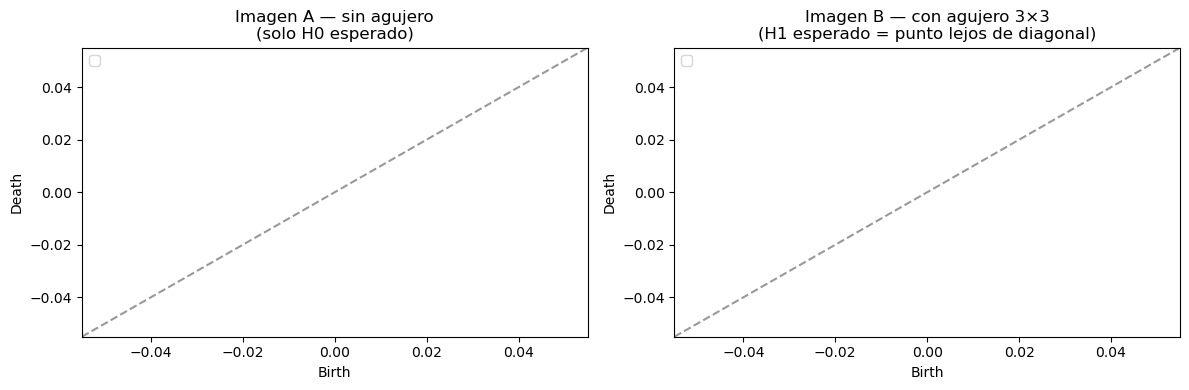

In [8]:
# graficamos los diagramas de persistencia (birth/death)
# cada punto es un hoyo: lejos de la diagonal = más persistente = más real

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, (diagrama, titulo) in enumerate(zip(diagramas, [
    "Imagen A — sin agujero\n(solo H0 esperado)",
    "Imagen B — con agujero 3×3\n(H1 esperado = punto lejos de diagonal)"
])):
    ax = axes[idx]
    # H0 = componentes conexas (dim=0), H1 = hoyos (dim=1)
    for dim, color, label in [(0, 'red', 'H0'), (1, 'blue', 'H1')]:
        puntos = diagrama[diagrama[:, 2] == dim]
        # filtramos los puntos vacíos (birth=death=0)
        puntos = puntos[~((puntos[:, 0] == 0) & (puntos[:, 1] == 0))]
        if len(puntos) > 0:
            ax.scatter(puntos[:, 0], puntos[:, 1], c=color, label=label, s=60)
    
    # dibujamos la diagonal (birth=death → persistencia=0)
    lim = ax.get_xlim()
    ax.plot([0, 1], [0, 1], 'k--', transform=ax.transAxes, alpha=0.4)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

### El Reto Principal

**Instrucciones**:

Procesamiento del Dataset de Kaggle:

- Tomen una muestra de 300 imágenes sanas y 300 defectuosas.
- Vital: Reduzcan la resolución a 32x32 píxeles (para que el complejo cúbico corra en segundos).
- Instancien CubicalPersistence y transformen los diagramas resultantes usando PersistenceImage.
- Aplánenlos para obtener un vector 1D por cada imagen.

In [ ]:
import os
from PIL import Image
from gtda.images import PersistenceImage

# rutas al dataset de casting (relativas al notebook)
ruta_def = "archive/casting_512x512/casting_512x512/def_front"
ruta_ok  = "archive/casting_512x512/casting_512x512/ok_front"

def cargar_imagenes(ruta, n=300):
    """Carga n imágenes de una carpeta,
    las convierte a escala de grises y las redimensiona a 32x32.
    El resize es vital: 512x512 haría el complejo cubico tardísimo."""
    imagenes = []
    archivos = sorted(os.listdir(ruta))[:n]  # tomamos los primeros n
    for archivo in archivos:
        if not archivo.endswith(('.jpeg', '.jpg', '.png')):
            continue
        img = Image.open(os.path.join(ruta, archivo)).convert("L")  # escala de grises
        img = img.resize((32, 32))                                   # reducimos a 32x32
        imagenes.append(np.array(img, dtype=np.float32))
    return np.array(imagenes[:n])

print("Cargando imágenes defectuosas...")
imgs_def = cargar_imagenes(ruta_def, 300)

print("Cargando imágenes sanas...")
imgs_ok  = cargar_imagenes(ruta_ok, 300)

print(f"Defectuosas: {imgs_def.shape}")  # esperamos (300, 32, 32)
print(f"Sanas:       {imgs_ok.shape}")

In [ ]:
# apilamos defectuosas (label=1) y sanas (label=0) en un solo dataset
X_imagenes = np.concatenate([imgs_def, imgs_ok], axis=0)  # (600, 32, 32)
y_labels   = np.array([1] * 300 + [0] * 300)              # 1=defectuosa, 0=sana

print(f"Dataset total: {X_imagenes.shape}")

# aplicamos CubicalPersistence sobre las 600 imágenes reales
# n_jobs=-1 usa todos los cores para ir más rápido
cp_real = CubicalPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagramas_reales = cp_real.fit_transform(X_imagenes)

print(f"Diagramas shape: {diagramas_reales.shape}")

In [ ]:
# convertimos los diagramas a imágenes de persistencia:
# son mapas de calor donde la intensidad refleja cuántos hoyos
# hay en cada región del espacio birth/death
# sigma controla el suavizado, n_bins la resolución del mapa
pi = PersistenceImage(sigma=0.1, n_bins=20, n_jobs=-1)
X_tda = pi.fit_transform(diagramas_reales)

print(f"Persistence images shape: {X_tda.shape}")

# aplanamos: cada imagen de persistencia → vector 1D
# esto nos permite usarlo con cualquier clasificador de sklearn
X_tda_flat = X_tda.reshape(X_tda.shape[0], -1)
print(f"Vectores topológicos shape: {X_tda_flat.shape}")

In [ ]:
# también preparamos los píxeles crudos para el modelo clásico
# 32x32 = 1024 variables por imagen
X_clasico = X_imagenes.reshape(X_imagenes.shape[0], -1)
print(f"Píxeles aplanados shape: {X_clasico.shape}")

### Benchmark: TDA vs Clásico

Entrenen un RandomForestClassifier comparando los enfoques:

1. **Modelo A (Clásico):**
Entrenado usando únicamente los píxeles aplanados (1024 variables).

2. **Modelo B (Topológico):**
Entrenado usando únicamente las Imágenes de Persistencia (Vectores Topológicos).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# dividimos con la misma semilla para que la comparación sea justa
# (los dos modelos ven exactamente el mismo train/test split)
X_tda_train, X_tda_test, y_train, y_test = train_test_split(
    X_tda_flat, y_labels, test_size=0.2, random_state=42
)
X_cl_train, X_cl_test, _, _ = train_test_split(
    X_clasico, y_labels, test_size=0.2, random_state=42  # misma semilla!
)

# guardamos los índices del test para usarlos en el Aha Moment
indices_test = np.arange(len(y_labels))
_, idx_test = train_test_split(indices_test, test_size=0.2, random_state=42)

print(f"Train: {len(y_train)} imágenes | Test: {len(y_test)} imágenes")

In [ ]:
# Modelo A: clásico — solo píxeles
rf_clasico = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clasico.fit(X_cl_train, y_train)
acc_clasico = accuracy_score(y_test, rf_clasico.predict(X_cl_test))

# Modelo B: topológico — vectores TDA
rf_tda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tda.fit(X_tda_train, y_train)
acc_tda = accuracy_score(y_test, rf_tda.predict(X_tda_test))

print(f"Modelo Clásico  (píxeles)  : {acc_clasico:.2%}")
print(f"Modelo TDA (topología): {acc_tda:.2%}")

### El "Aha Moment" (Test de Robustez)

Probablemente, ambos modelos obtengan un Accuracy similar (ej. 85%). Para demostrar el poder del TDA, ejecuten este test:

- **Reto**: Roten todas las imágenes del set de prueba (X_test) 90 grados, o gírenlas verticalmente (Flip). Vuelvan a evaluar ambos modelos.
- **Resultado**: El Modelo Clásico colapsará drásticamente (los píxeles se movieron). El Modelo TDA mantendrá su precisión casi intacta, porque un agujero sigue siendo un agujero, sin importar cómo rotes la pieza.

In [ ]:
# tomamos las imágenes originales del test y las rotamos 90°
X_img_test_orig = X_imagenes[idx_test]  # (120, 32, 32)
X_img_test_rot  = np.rot90(X_img_test_orig, k=1, axes=(1, 2))  # rotación 90°

# modelo clásico: aplanamos los píxeles rotados
# los píxeles cambiaron de posición → el modelo no los reconoce
X_cl_test_rot = X_img_test_rot.reshape(len(idx_test), -1)
acc_clasico_rot = accuracy_score(y_test, rf_clasico.predict(X_cl_test_rot))

# modelo TDA: recalculamos los diagramas de las imágenes rotadas
# los hoyos siguen siendo hoyos aunque rotes → la topología no cambia
diag_rot    = cp_real.transform(X_img_test_rot)
X_tda_rot   = pi.transform(diag_rot).reshape(len(idx_test), -1)
acc_tda_rot = accuracy_score(y_test, rf_tda.predict(X_tda_rot))

print("====== TEST DE ROBUSTEZ (rotación 90°) =====")
print(f"{'Modelo':<20} {'Normal':>10} {'Rotado':>10} {'Caída':>10}")
print("-" * 52)
print(f"{'Clásico (píxeles)':<20} {acc_clasico:>10.2%} {acc_clasico_rot:>10.2%} {acc_clasico - acc_clasico_rot:>10.2%}")
print(f"{'TDA (topología)':<20} {acc_tda:>10.2%} {acc_tda_rot:>10.2%} {acc_tda - acc_tda_rot:>10.2%}")
print()
print("Conclusión: el modelo TDA mantiene su precisión")
print("porque un agujero sigue siendo un agujero sin importar la rotación.")

In [ ]:
# visualización final: comparamos una imagen original vs rotada
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for i in range(4):
    axes[0, i].imshow(X_img_test_orig[i], cmap='gray')
    axes[0, i].set_title(f"Original\n({'Defectuosa' if y_test[i]==1 else 'Sana'})")
    axes[0, i].axis('off')

    axes[1, i].imshow(X_img_test_rot[i], cmap='gray')
    axes[1, i].set_title("Rotada 90°")
    axes[1, i].axis('off')

plt.suptitle("Original vs Rotada — la topología (hoyos) se preserva", fontsize=13)
plt.tight_layout()
plt.show()